In [196]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from utils import train_score_network, generate_initial_data, rollout, time_reversal, noise, time_reversal_bsde, train_phi_network, sample_gaussian_mixture
from network import ScoreNetwork, PhiNetwork

In [221]:
N = 10000  # number of samples
n = 2    # dimension of state
m = 2    # dimension of noise
T = 0.4   # terminal time
steps = 50  # number of time steps
dt = T / steps  # time step size


In [222]:
centers = torch.tensor([
    [ 7.0,  0.0],
    [ 1.5,  0.4],
    [ -1.0,  4.0],
    [ -2.0, -2.0],
])
X_0 = sample_gaussian_mixture(N, centers)

In [223]:
time_grid = torch.arange(0, steps+1) * dt

In [224]:
a = -2.0
sigma = 2.0

In [225]:
X = torch.zeros((steps+1, N, n))
X[0] = X_0

In [226]:
for i in range(steps):
    X[i+1] = X[i] + a * X[i] * dt + sigma * noise(dt, N, m)

Text(0.5, 0, 'Time Steps')

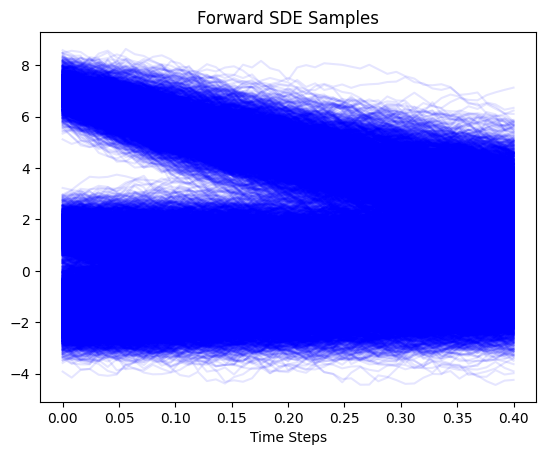

In [227]:
plt.figure()
plt.plot(time_grid, X[:, :, 0].numpy(), alpha=0.1, color='blue')
plt.title('Forward SDE Samples')
plt.xlabel('Time Steps')

Text(0.5, 1.0, 'Terminal Distribution Samples')

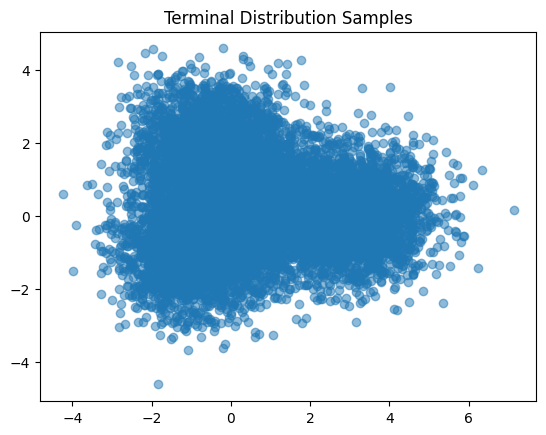

In [228]:
plt.figure()
plt.scatter(X[-1, :, 0].numpy(), X[-1, :, 1].numpy(), alpha=0.5)
plt.title('Terminal Distribution Samples')

Text(0.5, 1.0, 'Initial Distribution Samples')

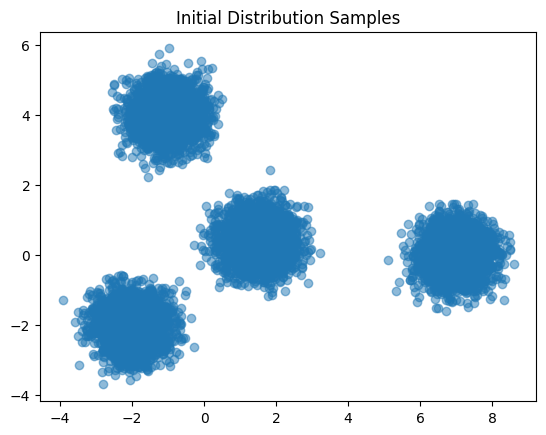

In [229]:
plt.figure()
plt.scatter(X[0, :, 0].numpy(), X[0, :, 1].numpy(), alpha=0.5)
plt.title('Initial Distribution Samples')

In [230]:
X[-1].mean(dim=0), X[-1].std(dim=0)

(tensor([0.5985, 0.2795]), tensor([1.8187, 1.3286]))

In [231]:
score_nn = ScoreNetwork(input_dim=n+1, out_dim=n, hidden_dim=64, num_blocks=4)
score_optimizer = torch.optim.AdamW(score_nn.parameters(), lr=1e-3, weight_decay=1e-4)
score_scheduler = torch.optim.lr_scheduler.StepLR(score_optimizer, step_size=500, gamma=0.9)

In [232]:
def g(x):
    """
    Diffusion function of X_t for a nonlinear system.
    Args:
        x (torch.Tensor): State vector. Shape (N, n)
    Returns:
        torch.Tensor: Diffusion matrix. Shape (N, n, m)
    """
    B = torch.eye(n) * sigma
    B = B.unsqueeze(0).repeat(x.shape[0], 1, 1)
    return B

In [233]:
score_loss_history = train_score_network(score_nn, X, time_grid, g, 1, score_optimizer, score_scheduler, batch_size=64, iterations=20000)

Iteration 0, Loss: 0.007173920050263405
Iteration 500, Loss: -1.7484217882156372
Iteration 1000, Loss: -3.113717555999756
Iteration 1500, Loss: -2.656615734100342
Iteration 2000, Loss: -2.347851514816284
Iteration 2500, Loss: -2.3302817344665527
Iteration 3000, Loss: -2.5173728466033936
Iteration 3500, Loss: -2.700866460800171
Iteration 4000, Loss: -2.3249692916870117
Iteration 4500, Loss: -3.198056697845459
Iteration 5000, Loss: -3.324620485305786
Iteration 5500, Loss: -3.024801731109619
Iteration 6000, Loss: -3.1712796688079834
Iteration 6500, Loss: -2.715444803237915
Iteration 7000, Loss: -3.242377758026123
Iteration 7500, Loss: -2.6915905475616455
Iteration 8000, Loss: -2.986616611480713
Iteration 8500, Loss: -2.583901882171631
Iteration 9000, Loss: -2.3842451572418213
Iteration 9500, Loss: -3.154407501220703
Iteration 10000, Loss: -2.6971983909606934
Iteration 10500, Loss: -3.1607542037963867
Iteration 11000, Loss: -2.617769241333008
Iteration 11500, Loss: -3.3747243881225586
Iter

In [234]:
time_grid.shape

torch.Size([51])

In [235]:
sample_steps = 50

In [236]:
# time reversal
X_rev = torch.zeros((sample_steps+1, N, n))
X_rev[-1] = torch.randn((N,n))

In [237]:
time_grid_sample = torch.linspace(0, T, sample_steps+1)

In [238]:
for i in range(sample_steps-1, -1, -1):
    t = time_grid_sample[i+1].repeat(N, 1)  # (N, 1)
    score = score_nn(X_rev[i+1,:,:], t).detach()  # (N, n)
    X_rev[i] = X_rev[i+1] - a * X_rev[i+1] * dt + 1.0*sigma * noise(dt, N, m) + sigma**2 * score * dt

Text(0.5, 0, 'Time Steps')

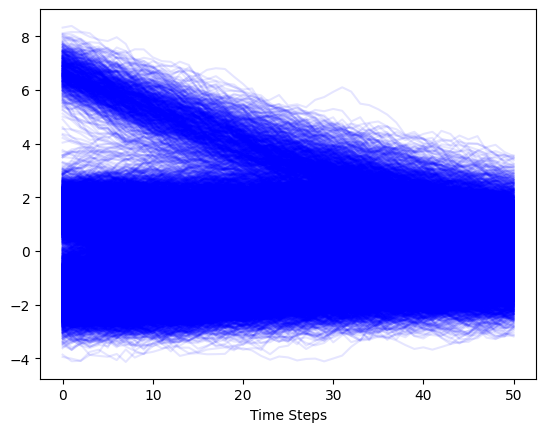

In [239]:
plt.figure()
plt.plot(X_rev[:, :, 0].numpy(), alpha=0.1, color='blue')
# plt.plot(X[:, :, 0].numpy(), alpha=0.1, color='red')
# plt.title('Backward SDE Samples')
plt.xlabel('Time Steps')

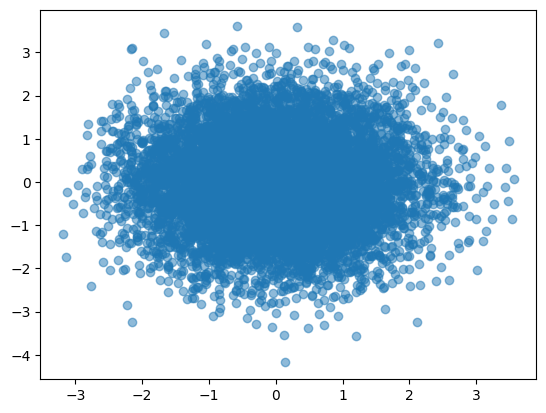

In [240]:
plt.figure()
plt.scatter(X_rev[-1, :, 0].numpy(), X_rev[-1, :, 1].numpy(), alpha=0.5)

In [241]:
from utils import MMD, kernel

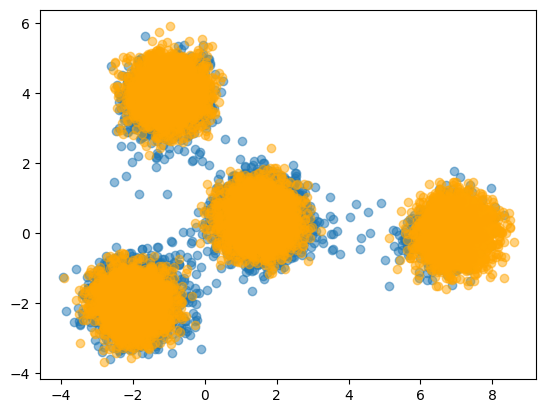

In [242]:
plt.figure()
plt.scatter(X_rev[0, :, 0].numpy(), X_rev[0, :, 1].numpy(), alpha=0.5)
plt.scatter(X_0[:, 0].numpy(), X_0[:, 1].numpy(), alpha=0.5, color='orange')

In [243]:
MMD(X[0], X_rev[0], kernel)

tensor(0.1870)

In [245]:
torch.save(score_nn.state_dict(), f'network/2dim_4gaussian_score_network_timesteps{steps}_a{a}_s{sigma}_asymmetric.pth')